# Plate — 4 × 6 Blind Holes with Variable Diameter & Depth

Edit the two lists in **Cell 2** to control every hole individually.

```
  col →  0    1    2    3
row 0  [ 0]  [ 1]  [ 2]  [ 3]
row 1  [ 4]  [ 5]  [ 6]  [ 7]
row 2  [ 8]  [ 9]  [10]  [11]
row 3  [12]  [13]  [14]  [15]
row 4  [16]  [17]  [18]  [19]
row 5  [20]  [21]  [22]  [23]
```

In [11]:
import gmsh
import meshio
import numpy as np
from pathlib import Path

OUT_DIR = Path("../mesh")
OUT_DIR.mkdir(exist_ok=True)

## 1 — Parameters  *(edit here)*

In [19]:
# ── Plate ────────────────────────────────────────────────────────────────────
plate_lx  = 10.0   # length  [mm]
plate_ly  = 10.0   # width   [mm]
plate_lz  =  2.0   # thickness [mm]

# ── Hole grid ────────────────────────────────────────────────────────────────
N_COLS = 1
N_ROWS = 1
N_HOLES = N_COLS * N_ROWS   # 24

# Margin from plate edge to hole centres [mm]
margin_x = 5.0
margin_y = 5.0

# ── Per-hole lists  (index = row*N_COLS + col) ───────────────────────────────
# Diameters [mm]  — one value per hole, row-major order
diameters = [
    5.0, 
]

# Depths [mm]  — must be < plate_lz (blind!)
depths = [
    1.0, 
]

# ── Mesh sizes ───────────────────────────────────────────────────────────────
lc_far  = 1.0   # coarse (far from holes)
lc_near =  .1   # fine   (at hole walls)
refine_dist = 10.0  # ramp distance [mm]

# ── Validate ─────────────────────────────────────────────────────────────────
assert len(diameters) == N_HOLES, f"Need {N_HOLES} diameters, got {len(diameters)}"
assert len(depths)    == N_HOLES, f"Need {N_HOLES} depths, got {len(depths)}"
for i, (d, h) in enumerate(zip(diameters, depths)):
    assert h < plate_lz, f"Hole {i}: depth {h} >= plate thickness {plate_lz} — not blind!"
    assert d / 2 < min(margin_x, margin_y), \
        f"Hole {i}: radius {d/2} may overlap plate edge"
print("Parameters OK")

Parameters OK


## 2 — Geometry

In [20]:
gmsh.initialize()
gmsh.model.add("plate_multi_holes")
occ = gmsh.model.occ

# Plate
plate = occ.addBox(0, 0, 0, plate_lx, plate_ly, plate_lz)

# Hole grid centres (evenly spaced between margins)
xs = np.linspace(margin_x, plate_lx - margin_x, N_COLS)
ys = np.linspace(margin_y, plate_ly - margin_y, N_ROWS)

# Check minimum wall thickness between adjacent holes
dx_grid = xs[1] - xs[0] if N_COLS > 1 else np.inf
dy_grid = ys[1] - ys[0] if N_ROWS > 1 else np.inf
for row in range(N_ROWS):
    for col in range(N_COLS):
        i = row * N_COLS + col
        r = diameters[i] / 2
        if col < N_COLS - 1:
            r_next = diameters[i + 1] / 2
            wall = dx_grid - r - r_next
            assert wall > 0, f"Holes {i} and {i+1} overlap horizontally (wall={wall:.1f} mm)"
        if row < N_ROWS - 1:
            r_next = diameters[i + N_COLS] / 2
            wall = dy_grid - r - r_next
            assert wall > 0, f"Holes {i} and {i+N_COLS} overlap vertically (wall={wall:.1f} mm)"

print(f"Grid spacing: dx={dx_grid:.1f} mm  dy={dy_grid:.1f} mm")

# Create all cylinders (drill from top face downward)
cylinders = []
hole_info = []   # (cx, cy, depth, radius) for each hole
for row in range(N_ROWS):
    for col in range(N_COLS):
        i   = row * N_COLS + col
        cx, cy = xs[col], ys[row]
        r   = diameters[i] / 2
        d   = depths[i]
        cyl = occ.addCylinder(cx, cy, plate_lz, 0, 0, -d, r)
        cylinders.append((3, cyl))
        hole_info.append((cx, cy, d, r))

# Single boolean cut: plate − all cylinders
result, _ = occ.cut(
    [(3, plate)],
    cylinders,
    removeObject=True,
    removeTool=True,
)

occ.synchronize()

vol_tag = result[0][1]
n_surfaces = len(gmsh.model.getEntities(2))
print(f"Volume tag: {vol_tag}  |  Surfaces after cut: {n_surfaces}")

Grid spacing: dx=inf mm  dy=inf mm
Volume tag: 1  |  Surfaces after cut: 8                                                                                        


## 3 — Physical groups

In [21]:
tol = 1e-4

bottom_tags, top_tags, side_tags, hole_wall_tags, hole_floor_tags = [], [], [], [], []

for _, tag in gmsh.model.getEntities(2):
    xmin, ymin, zmin, xmax, ymax, zmax = gmsh.model.getBoundingBox(2, tag)
    cx = (xmin + xmax) / 2
    cy = (ymin + ymax) / 2
    cz = (zmin + zmax) / 2

    if zmax < tol:                              # bottom face (z ≈ 0)
        bottom_tags.append(tag)
    elif zmin > plate_lz - tol:                 # top face (z ≈ plate_lz)
        top_tags.append(tag)
    elif (xmax - xmin < tol or                  # side walls (flat, vertical)
          ymax - ymin < tol):
        side_tags.append(tag)
    else:
        # Distinguish hole floor (horizontal disc) from cylindrical wall
        is_floor = (zmax - zmin) < tol          # flat → floor
        if is_floor:
            hole_floor_tags.append(tag)
        else:
            hole_wall_tags.append(tag)

gmsh.model.addPhysicalGroup(2, bottom_tags,     tag=1, name="bottom")
gmsh.model.addPhysicalGroup(2, top_tags,        tag=2, name="top")
gmsh.model.addPhysicalGroup(2, side_tags,       tag=3, name="sides")
gmsh.model.addPhysicalGroup(2, hole_wall_tags,  tag=4, name="hole_walls")
gmsh.model.addPhysicalGroup(2, hole_floor_tags, tag=5, name="hole_floors")
gmsh.model.addPhysicalGroup(3, [vol_tag],       tag=6, name="volume")

print(f"bottom: {len(bottom_tags)}  top: {len(top_tags)}  sides: {len(side_tags)}")
print(f"hole walls: {len(hole_wall_tags)}  hole floors: {len(hole_floor_tags)}")

bottom: 1  top: 1  sides: 4
hole walls: 1  hole floors: 1


## 4 — Mesh  (refined at hole walls)

In [22]:
# Distance field from all hole surfaces (walls + floors)
all_hole_tags = hole_wall_tags + hole_floor_tags

f_dist = gmsh.model.mesh.field.add("Distance")
gmsh.model.mesh.field.setNumbers(f_dist, "SurfacesList", all_hole_tags)

f_thresh = gmsh.model.mesh.field.add("Threshold")
gmsh.model.mesh.field.setNumber(f_thresh, "InField",  f_dist)
gmsh.model.mesh.field.setNumber(f_thresh, "SizeMin",  lc_near)
gmsh.model.mesh.field.setNumber(f_thresh, "SizeMax",  lc_far)
gmsh.model.mesh.field.setNumber(f_thresh, "DistMin",  0.0)
gmsh.model.mesh.field.setNumber(f_thresh, "DistMax",  refine_dist)

gmsh.model.mesh.field.setAsBackgroundMesh(f_thresh)

gmsh.option.setNumber("Mesh.MeshSizeExtendFromBoundary", 0)
gmsh.option.setNumber("Mesh.MeshSizeFromPoints",        0)
gmsh.option.setNumber("Mesh.MeshSizeFromCurvature",     0)

gmsh.model.mesh.generate(3)
gmsh.model.mesh.optimize("Netgen")

msh_file = str(OUT_DIR / "plate_multi_holes.msh")
gmsh.write(msh_file)

info = gmsh.model.mesh.getNodes()
print(f"Nodes : {len(info[0])}")
print(f"Wrote : {msh_file}")

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 13 (Circle)
Info    : [ 10%] Meshing curve 14 (Line)
Info    : [ 20%] Meshing curve 15 (Circle)
Info    : [ 30%] Meshing curve 16 (Line)
Info    : [ 30%] Meshing curve 17 (Line)
Info    : [ 40%] Meshing curve 18 (Line)
Info    : [ 50%] Meshing curve 19 (Line)
Info    : [ 50%] Meshing curve 20 (Line)
Info    : [ 60%] Meshing curve 21 (Line)
Info    : [ 70%] Meshing curve 22 (Line)
Info    : [ 70%] Meshing curve 23 (Line)
Info    : [ 80%] Meshing curve 24 (Line)
Info    : [ 90%] Meshing curve 25 (Line)
Info    : [ 90%] Meshing curve 26 (Line)
Info    : [100%] Meshing curve 27 (Line)
Info    : Done meshing 1D (Wall 0.0586652s, CPU 0.057123s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 7 (Cylinder, Frontal-Delaunay)
Info    : [ 20%] Meshing surface 8 (Plane, Frontal-Delaunay)
Info    : [ 30%] Meshing surface 9 (Plane, Frontal-Delaunay)
Info    : [ 40%] Meshing surface 10 (Plane, Frontal-Delaunay)
Info    : [ 60%] Meshing s

## 5 — Export to XDMF

In [23]:
m = meshio.read(msh_file)

def write_xdmf(path, cell_type, m):
    cells = m.cells_dict.get(cell_type)
    if cells is None or len(cells) == 0:
        print(f"No {cell_type} cells found, skipping {path}")
        return
    data = m.cell_data_dict.get("gmsh:physical", {}).get(cell_type)
    meshio.write(
        path,
        meshio.Mesh(
            points=m.points,
            cells=[(cell_type, cells)],
            cell_data={"markers": [data]} if data is not None else {},
        ),
    )
    print(f"Wrote {path}  ({len(cells)} cells)")

write_xdmf(str(OUT_DIR / "plate_multi_holes.xdmf"),          "tetra",    m)
write_xdmf(str(OUT_DIR / "plate_multi_holes_surfaces.xdmf"), "triangle", m)


Wrote ../mesh/plate_multi_holes.xdmf  (102944 cells)
Wrote ../mesh/plate_multi_holes_surfaces.xdmf  (15882 cells)


## 6 — Visualise hole layout + mesh preview

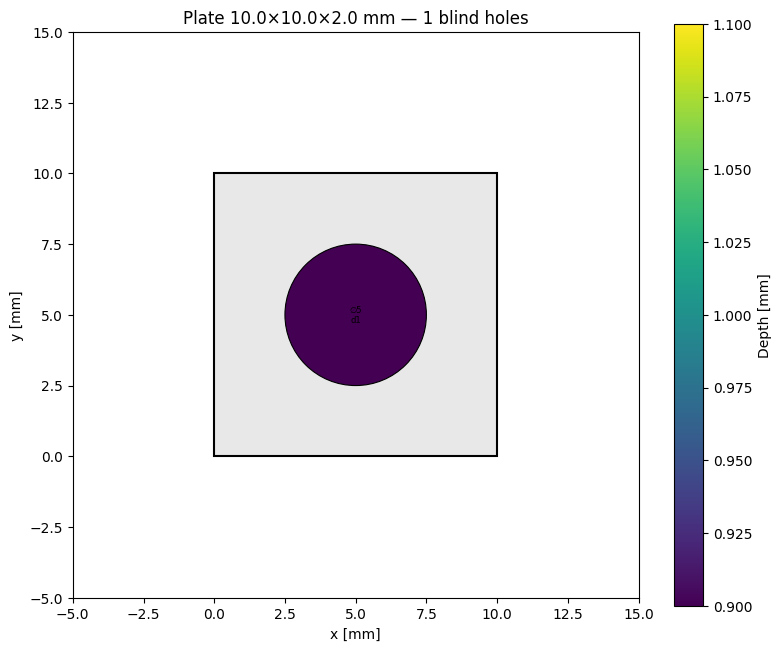

In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(8, 10))
ax.set_aspect("equal")
ax.add_patch(patches.Rectangle((0, 0), plate_lx, plate_ly,
                                linewidth=1.5, edgecolor="k", facecolor="#e8e8e8"))

cmap = plt.cm.viridis
depth_norm = plt.Normalize(min(depths), max(depths))

for row in range(N_ROWS):
    for col in range(N_COLS):
        i  = row * N_COLS + col
        cx, cy = xs[col], ys[row]
        r  = diameters[i] / 2
        d  = depths[i]
        color = cmap(depth_norm(d))
        ax.add_patch(patches.Circle((cx, cy), r, color=color, ec="k", linewidth=0.8))
        ax.text(cx, cy, f"∅{diameters[i]:.0f}\nd{d:.0f}",
                ha="center", va="center", fontsize=6, color="white" if d > 17 else "black")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=depth_norm)
plt.colorbar(sm, ax=ax, label="Depth [mm]", shrink=0.6)
ax.set_xlim(-5, plate_lx + 5)
ax.set_ylim(-5, plate_ly + 5)
ax.set_xlabel("x [mm]")
ax.set_ylabel("y [mm]")
ax.set_title(f"Plate {plate_lx}×{plate_ly}×{plate_lz} mm — {N_HOLES} blind holes")
plt.tight_layout()
plt.savefig(str(OUT_DIR / "plate_multi_holes_layout.png"), dpi=150)
plt.show()

In [10]:
# gmsh.fltk.run()   # ← uncomment for interactive Gmsh GUI
gmsh.finalize()
print("Done.")

Done.
